Quels facteurs expliquent l'insatisfaction client (notes basses) sur la marketplace Olist ?

In [3]:
#Importation des librairies pour l'exploration
import pandas as pd
import seaborn as sns
from pathlib import Path


In [11]:
#Chemin pour d'accès aux données
RAW_DATA_DIR = Path("../../data/raw")

#Listes des fichiers utilisés
FICHIERS = ["olist_customers_dataset.csv",
         "olist_geolocation_dataset.csv",
         "olist_order_items_dataset.csv",
         "olist_order_payments_dataset.csv",
         "olist_order_reviews_dataset.csv",
         "olist_orders_dataset.csv",
         "olist_products_dataset.csv",
         "olist_sellers_dataset.csv",
         "product_category_name_translation.csv"]

#Création d'une fonction pour récupérer les données et les stockés dans un dictionnaire
def chargement_donnees(liste_fichiers):
    dict_df = dict()
    for nom_fichier in liste_fichiers:
        dict_df[nom_fichier] = pd.read_csv(RAW_DATA_DIR / nom_fichier)
    return dict_df

data = chargement_donnees(FICHIERS)

In [19]:
#Attribution de chaque data frame pour l'exploration
df_customer = data[FICHIERS[0]]
df_geolocation = data[FICHIERS[1]]
df_orders_items = data[FICHIERS[2]]
df_order_payments = data[FICHIERS[3]]
df_order_reviews = data[FICHIERS[4]]
df_orders = data[FICHIERS[5]]
df_products = data[FICHIERS[6]]
df_sellers = data[FICHIERS[7]]
product_categories_name = data[FICHIERS[8]]


Pour chaque DATA set on va s'intéresser à son utilité pour notre problématique.

In [29]:
for donnees, df in data.items():
    print(donnees)
    display(df.head(5))

olist_customers_dataset.csv


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


olist_geolocation_dataset.csv


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


olist_order_items_dataset.csv


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


olist_sellers_dataset.csv


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


product_category_name_translation.csv


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<Axes: xlabel='review_score', ylabel='Count'>

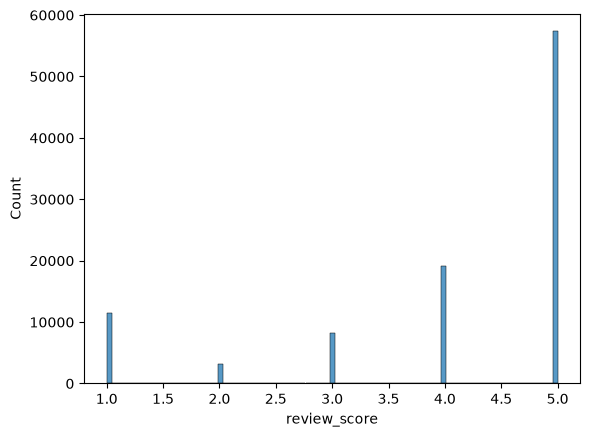

In [40]:
# Order_review analyse

sns.histplot(data=df_order_reviews,x="review_score")
